# Fingerprint Presentation Attack Detection (FPAD) — Comprehensive Research Pipeline

Welcome to **`main.ipynb`**, a publication-ready, self-contained research notebook for Fingerprint Presentation Attack Detection (FPAD) using **Local Binary Patterns (LBP)**, **Support Vector Machines (SVM)**, and **K-Nearest Neighbors (KNN)**.

### Protocol Architecture:
1. **Explicit Feature Extraction**: Preprocessing (CLAHE + Target Resize 300x300) $\rightarrow$ Uniform LBP ($P=8, R=1$) over an $8 \times 8$ grid $\rightarrow$ **640-dimensional feature vector**.
2. **Identity-Isolated Data Splitting**: Subject-wise `GroupShuffleSplit` (80% Train Subjects / 20% Test Subjects) guarantees **zero identity leakage** between training and test sets.
3. **Cross-Validation / Validation Protocol**: 5-Fold Stratified Cross-Validation (`StratifiedKFold(n_splits=5)`) is performed inside `GridSearchCV` during training for hyperparameter tuning.
4. **Balanced Training vs Natural Imbalanced Testing**: The training set is dynamically undersampled to balance Genuine and Fake classes, while the test set retains real-world imbalanced distributions.
5. **Real-Time Stage Execution**: KNN models are trained and evaluated first, followed by SVM models. Every phase runs inline in its own cell.
6. **Preserved Results**: All full dataset outputs dump into `results_full/` so existing `results/` is completely preserved.


In [1]:
# ============================================================
# WINDOWS + PYTHON 3.13 MULTI-CORE FIX — safe registry override
# ============================================================
import joblib.parallel as _jpar
import os as _os
if _os.name == 'nt':
    _jpar.BACKENDS['loky'] = _jpar.BACKENDS['threading']
    _jpar.DEFAULT_BACKEND = 'threading'
    print('Windows multi-core fix applied (threading backend).')

import sys
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Add src to sys.path
sys.path.append(os.path.abspath('src'))

# MUST set N_JOBS env var BEFORE importing config (config reads it at import time)
os.environ['N_JOBS'] = '-1'

# Set output directory to results_full to preserve existing results/
OUTPUT_DIR = os.path.abspath('results_full')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Now import config (it will pick up N_JOBS=-1 from env)
import config
config.RESULTS_DIR = OUTPUT_DIR

from config import SOCOFING_DIR, FVC2000_DIR, RANDOM_STATE, LBP_POINTS, LBP_RADIUS, LBP_METHOD, LBP_BLOCKS, LBP_BINS
from preprocess import preprocess_image
from features import extract_lbp_features
from models import get_svm_pipeline, get_knn_pipeline
from evaluation_pad import evaluate_pad_model
from socofing_experiment import load_socofing_image_paths, prepare_experiment_data, extract_subject_id
from lbp_examples import generate_lbp_examples
from main import load_fvc2000_data, run_pipeline

print('Pipeline successfully initialized.')
print(f'Parallel CPU Jobs: N_JOBS = {config.N_JOBS}')
print(f'Results Directory: {OUTPUT_DIR}')


Windows multi-core fix applied (threading backend).
Pipeline successfully initialized.
Parallel CPU Jobs: N_JOBS = -1
Results Directory: c:\Users\Oseni\Desktop\Data Science Implementation\fingerprint-scoofing\results_full


## 1. Local Binary Pattern (LBP) Feature Extraction Process

Every fingerprint image undergoes a 4-step feature extraction pipeline:
$$\text{Raw Image} \xrightarrow{\text{Resize 300}\times\text{300 + CLAHE}} \text{Preprocessed Grayscale} \xrightarrow{\text{Uniform LBP }(P=8, R=1)} \text{LBP Map} \xrightarrow{8 \times 8 \text{ Spatial Grid}} \mathbf{640\text{-dim Vector}}$$

- **Sampling Points ($P$)**: 8
- **Radius ($R$)**: 1
- **LBP Method**: Uniform (produces 10 distinct pattern codes per block: 8 uniform + 1 non-uniform)
- **Spatial Division**: $8 \times 8 = 64$ blocks
- **Feature Dimension**: $64 \text{ blocks} \times 10 \text{ bins/block} = \mathbf{640 \text{ features}}$


In [2]:
# Demonstrate LBP feature extraction on a sample image from the dataset
sample_real_dir = os.path.join(SOCOFING_DIR, "Real")
sample_files = [f for f in os.listdir(sample_real_dir) if f.lower().endswith('.bmp')]
sample_path = os.path.join(sample_real_dir, sample_files[0])

# Step 1: Preprocess Image (CLAHE + Target Resize 300x300)
img_prep = preprocess_image(sample_path)

# Step 2: Extract LBP Features
features = extract_lbp_features(img_prep)

print("========================================================================")
print("  EXPLICIT FEATURE EXTRACTION INSPECTION")
print("========================================================================")
print(f"Sample Image Path       : {sample_path}")
print(f"Preprocessed Image Shape: {img_prep.shape} (H=300, W=300)")
print(f"Preprocessed Data Type  : {img_prep.dtype}")
print(f"Extracted Feature Shape : {features.shape} (640-dimensional vector)")
print(f"Feature Data Type       : {features.dtype}")
print(f"Feature Range           : Min = {features.min():.5f}, Max = {features.max():.5f}")
print(f"Feature Mean            : {features.mean():.5f}")
print(f"First 20 Feature Values : {features[:20]}")
print("========================================================================")

# Verify dimensionality
assert features.shape == (640,), f"Expected (640,), got {features.shape}"
assert not np.isnan(features).any(), "Feature vector contains NaNs"
print("✓ Feature vector mathematically verified: 640 dimensions, valid float32.")


  EXPLICIT FEATURE EXTRACTION INSPECTION
Sample Image Path       : c:\Users\Oseni\Desktop\Data Science Implementation\fingerprint-scoofing\archive(2)\SOCOFing\Real\100__M_Left_index_finger.BMP
Preprocessed Image Shape: (300, 300) (H=300, W=300)
Preprocessed Data Type  : uint8
Extracted Feature Shape : (640,) (640-dimensional vector)
Feature Data Type       : float32
Feature Range           : Min = 0.00000, Max = 0.74753
Feature Mean            : 0.10000
First 20 Feature Values : [0.00073046 0.02118335 0.         0.00876552 0.07669832 0.22132944
 0.         0.00803506 0.6311176  0.03214025 0.         0.01680058
 0.         0.04821037 0.12783054 0.19576333 0.01607012 0.04894083
 0.5281227  0.01826151]
✓ Feature vector mathematically verified: 640 dimensions, valid float32.


Displaying: genuine_lbp.png


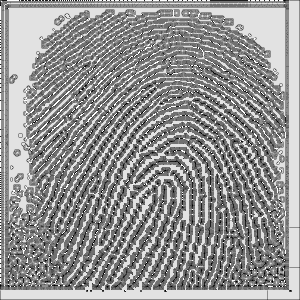

Displaying: easy_lbp.png


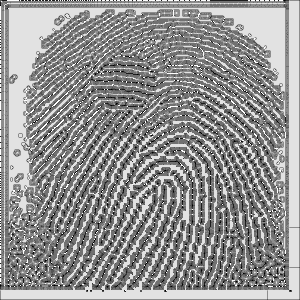

Displaying: medium_lbp.png


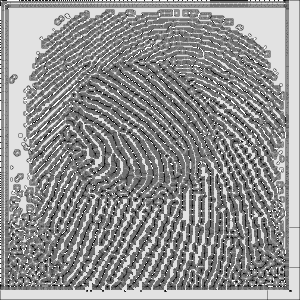

Displaying: hard_lbp.png


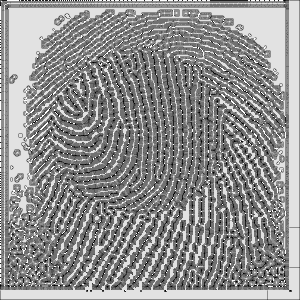

In [3]:
# Display LBP visualisation examples
lbp_ex_dirs = [
    os.path.join('results', 'lbp_examples'),
    os.path.join('results_full', 'lbp_examples'),
]
shown = False
for img_name in ['genuine_lbp.png', 'easy_lbp.png', 'medium_lbp.png', 'hard_lbp.png']:
    for base in lbp_ex_dirs:
        full = os.path.join(base, img_name)
        if os.path.exists(full):
            print(f'Displaying: {img_name}')
            display(Image(filename=full))
            shown = True
            break
if not shown:
    print('LBP visualisations will appear after Section 3 setup cell runs.')


## 2. FVC2000 Benchmark Protocol & Splitting

### FVC2000 Splitting Protocol:
- **Set B (`Db*_b`, fingers 101–110)**: Used exclusively for **Training / Parameter Tuning** (80 images/folder = 320 total).
- **Set A (`Db*_a`, fingers 1–100)**: Used exclusively for **Benchmark Testing** (800 images/folder = 3,200 total).
- **Genuine (Class 1)**: Db1, Db2, Db3 (real optical/capacitive hardware sensors).
- **Fake (Class 0)**: Db4 (SFinGe mathematical synthetic fingerprint generator).


In [4]:
X_train_fvc, X_test_fvc, y_train_fvc, y_test_fvc = load_fvc2000_data()

print("\n============================================================")
print("  FVC2000 DATA SPLITTING BREAKDOWN")
print("============================================================")
print(f"Training Matrix Shape  : {X_train_fvc.shape} (N_samples={X_train_fvc.shape[0]}, N_features={X_train_fvc.shape[1]})")
print(f"Testing Matrix Shape   : {X_test_fvc.shape} (N_samples={X_test_fvc.shape[0]}, N_features={X_test_fvc.shape[1]})")
print(f"Training Class Dist.   : Genuine (1) = {(y_train_fvc==1).sum()}, Fake (0) = {(y_train_fvc==0).sum()} [Balanced]")
print(f"Testing Class Dist.    : Genuine (1) = {(y_test_fvc==1).sum()}, Fake (0) = {(y_test_fvc==0).sum()} [3:1 Imbalance]")
print("============================================================")

# Run FVC2000 Training & Evaluation
run_pipeline("FVC2000", X_train_fvc, X_test_fvc, y_train_fvc, y_test_fvc)


Loading FVC2000 data...
  [TRAIN] Loading 80 images from Db1_b (label=1)...
  [TEST] Loading 800 images from Db1_a (label=1)...
  [TRAIN] Loading 80 images from Db2_b (label=1)...
  [TEST] Loading 800 images from Db2_a (label=1)...
  [TRAIN] Loading 80 images from Db3_b (label=1)...
  [TEST] Loading 800 images from Db3_a (label=1)...
  [TRAIN] Loading 80 images from Db4_b (label=0)...
  [TEST] Loading 800 images from Db4_a (label=0)...
  [BALANCE] Undersampled to 80 samples per class (total training: 160)

FVC2000 — Train: 160 samples | Test: 3200 samples | Feature dim: 640
  Train class distribution — Genuine: 80 | Fake: 80
  Test  class distribution — Genuine: 2400  | Fake: 800

  FVC2000 DATA SPLITTING BREAKDOWN
Training Matrix Shape  : (160, 640) (N_samples=160, N_features=640)
Testing Matrix Shape   : (3200, 640) (N_samples=3200, N_features=640)
Training Class Dist.   : Genuine (1) = 80, Fake (0) = 80 [Balanced]
Testing Class Dist.    : Genuine (1) = 2400, Fake (0) = 800 [3:1 Imba

## 3. SOCOFing Biometric Data Splitting Protocol & Validation Strategy

### Publication-Grade Data Isolation (`GroupShuffleSplit` by Subject ID)

- **Filename Subject Extraction**: Filenames follow `[SubjectID]_[Gender]_[Hand]_[Finger].BMP` (e.g., `100__M_Left_index_finger.BMP` → **Subject 100**).

- **Identity Isolation**: We split the dataset by **Subject ID** (80% Train Subjects / 20% Test Subjects).

  - **Training Set**: Contains 100% of images belonging to 80% of the subjects. The training set is dynamically undersampled to balance Genuine and Fake counts.

  - **Validation Set**: 5-Fold Stratified Cross-Validation (`StratifiedKFold(n_splits=5)`) is performed *inside the training set* during `GridSearchCV` parameter tuning.

  - **Testing Set**: Contains 100% of images belonging to the remaining unseen 20% of subjects. The test set retains the natural real-world class imbalance.

### Where Does the Data Go? Example: Altered-Medium Dataset

Users often ask: *"If Altered-Medium has 17,067 fake images and 6,000 genuine images, why does the test confusion matrix only sum to around 4,600 images?"*

Here is exactly how the dataset is partitioned during the `GroupShuffleSplit` process to prevent bias and data leakage:

1. **Total Dataset**: 6,000 Genuine + 17,067 Fake = **23,067 total images** (across approximately 600 unique subjects).

2. **Subject Split (80/20)**:

   - **Train Subjects (80%)**: Approximately 480 subjects (~4,800 Genuine + ~13,600 Fake images).

   - **Test Subjects (20%)**: Approximately 120 subjects (~1,200 Genuine + ~3,467 Fake images).

3. **Training Set Balancing**: Machine learning models such as SVM and KNN can perform poorly when trained on highly imbalanced data, for example, when there are approximately three times more Fake images than Genuine images.

   - We **undersample** the majority class in the training set.

   - We keep all 4,800 Genuine training images and randomly select exactly 4,800 Fake images to match them.

   - The remaining approximately 8,800 Fake images from the training subjects are **discarded**. They cannot be used for testing because their subjects are already present in the training set, which would cause identity leakage.

4. **Final Test Set Evaluation**: The confusion matrix evaluates only the unseen test subjects.

   - **Confusion Matrix Sum**: Approximately 1,200 Genuine + approximately 3,467 Fake = **approximately 4,667 total images** evaluated.

> **Conclusion:** This rigorous split ensures that the model never sees the same fingerprint identity in both the training and test sets, thereby preventing identity-based data leakage. Undersampling is applied only to the training data, while the test set retains its natural class distribution. The unused training images are therefore excluded from model fitting and testing to preserve the integrity of the experimental evaluation.

In [5]:
print('Generating LBP verification visual examples...')
generate_lbp_examples(SOCOFING_DIR)

real_paths, _ = load_socofing_image_paths(SOCOFING_DIR, 'Easy')
_, easy_paths = load_socofing_image_paths(SOCOFING_DIR, 'Easy')
_, med_paths  = load_socofing_image_paths(SOCOFING_DIR, 'Medium')
_, hard_paths = load_socofing_image_paths(SOCOFING_DIR, 'Hard')
_, all_fake_paths = load_socofing_image_paths(SOCOFING_DIR, 'All')

# ============================================================
# SET SAMPLE_FRACTION HERE
#   1.0  = 100% full dataset (~55,000 images, ~35-45 min on 8 cores)
#   0.05 = 5%  dry-run (~2,750 images, ~2-3 min on 8 cores)
#   0.01 = 1%  quick test (~550 images, ~30 sec on 8 cores)
#   0.005 = 0.5% minimum test (~275 images, ~15 sec on 8 cores)
# NOTE: Values below 0.005 (< 30 genuine images) are auto-clamped
# ============================================================
SAMPLE_FRACTION = 1  # Change this: 0.01 for quick test, 1.0 for full run

# Validate fraction is meaningful before running experiments
genuine_total = len(real_paths)
gen_sample = max(1, int(genuine_total * SAMPLE_FRACTION)) if SAMPLE_FRACTION < 1.0 else genuine_total
MIN_SAFE = 30
if gen_sample < MIN_SAFE:
    clamped = MIN_SAFE / genuine_total
    print(f'[WARNING] SAMPLE_FRACTION={SAMPLE_FRACTION} gives only {gen_sample} genuine images.')
    print(f'[WARNING] Auto-clamped to {clamped:.4f} ({MIN_SAFE} genuine images minimum).')
    print('[WARNING] Use at least SAMPLE_FRACTION=0.005 for stable results.')
else:
    print(f'SAMPLE_FRACTION={SAMPLE_FRACTION} -> ~{gen_sample} genuine images. Safe to proceed.')

def calculate_split_counts(genuine_files, fake_files, sample_frac=1.0, random_state=42):
    if 0.0 < sample_frac < 1.0:
        gen_n = max(MIN_SAFE, int(len(genuine_files) * sample_frac))
        fake_n = max(MIN_SAFE, int(len(fake_files) * sample_frac))
        genuine_files = genuine_files[:gen_n]
        fake_files = fake_files[:fake_n]

    all_files = genuine_files + fake_files
    labels = np.array([1]*len(genuine_files) + [0]*len(fake_files))
    groups = np.array([extract_subject_id(f) for f in all_files])

    from sklearn.model_selection import GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
    train_idx, test_idx = next(gss.split(all_files, labels, groups=groups))

    train_subjects = len(np.unique(groups[train_idx]))
    test_subjects  = len(np.unique(groups[test_idx]))
    train_gen       = int((labels[train_idx] == 1).sum())
    train_fake_raw  = int((labels[train_idx] == 0).sum())
    train_bal       = min(train_gen, train_fake_raw) * 2
    test_gen        = int((labels[test_idx] == 1).sum())
    test_fake       = int((labels[test_idx] == 0).sum())

    return {
        'Total Images': len(all_files),
        'Train Subjects': train_subjects,
        'Test Subjects': test_subjects,
        'Train Genuine (Raw)': train_gen,
        'Train Fake (Raw)': train_fake_raw,
        'Train Balanced Total': train_bal,
        'Test Genuine': test_gen,
        'Test Fake': test_fake,
        'Test Total': len(test_idx)
    }

split_data = []
for name, f_paths in [('Easy', easy_paths), ('Medium', med_paths), ('Hard', hard_paths), ('Combined', all_fake_paths)]:
    counts = calculate_split_counts(real_paths, f_paths, SAMPLE_FRACTION, RANDOM_STATE)
    counts['Experiment'] = name
    split_data.append(counts)

df_splits = pd.DataFrame(split_data)
cols_order = ['Experiment', 'Total Images', 'Train Subjects', 'Test Subjects',
              'Train Genuine (Raw)', 'Train Fake (Raw)', 'Train Balanced Total',
              'Test Genuine', 'Test Fake', 'Test Total']

print('========================================================================================')
print('  SOCOFing EXPERIMENT DATA SPLITTING & SUBJECT ISOLATION TABLE')
print('========================================================================================')
display(df_splits[cols_order])

# Global results list to store experiment metrics
all_results = []


Generating LBP verification visual examples...
  Saved LBP example images and 640-dim feature CSV to c:\Users\Oseni\Desktop\Data Science Implementation\fingerprint-scoofing\results_full\lbp_examples/
SAMPLE_FRACTION=1 -> ~6000 genuine images. Safe to proceed.
  SOCOFing EXPERIMENT DATA SPLITTING & SUBJECT ISOLATION TABLE


,Experiment,Total Images,Train Subjects,Test Subjects,Train Genuine (Raw),Train Fake (Raw),Train Balanced Total,Test Genuine,Test Fake,Test Total
0,Easy,23931,480,120,4800,14346,9600,1200,3585,4785
1,Medium,23067,480,120,4800,13665,9600,1200,3402,4602
2,Hard,20272,480,120,4800,11461,9600,1200,2811,4011
3,Combined,55270,480,120,4800,39472,9600,1200,9798,10998


## 4. KNN Experiments (Running K-Nearest Neighbors First)

Execute KNN across all 4 difficulty levels: Easy, Medium, Hard, Combined.

### Step 4.1: KNN on Easy Dataset

SOCOFing EASY — KNN EXPERIMENT
Raw Dataset  : 6000 genuine  +  17931 Altered-Easy fake
              Total = 23931 images before split
Sample Frac  : 1 ("1.0" = full dataset, "0.01" = 1% test run)
  Extracting LBP features for 19146 training images and 4785 testing images...
After Split  (80/20 GroupShuffleSplit by subject):
  Train      : 9600 images (4800 genuine + 4800 fake, balanced)
  Test       : 4785 images (1200 genuine + 3585 fake, natural imbalance)
  Confusion matrix totals should sum to: 4785
  Feature dim: 640
Fitting 5 folds for each of 14 candidates, totalling 70 fits

════════════════════════════════════════════════════════════════
  KNN RESULTS  ·  Experiment: EASY
════════════════════════════════════════════════════════════════
  DATASET SIZES
    Training  :   9600 images  (4800 genuine  +  4800 fake)  [balanced undersampled]
    Test      :   4785 images  (1200 genuine  +  3585 fake)  [natural imbalance]
    Features  : 640-dim LBP histogram  (8×8 blocks × 10 bins)


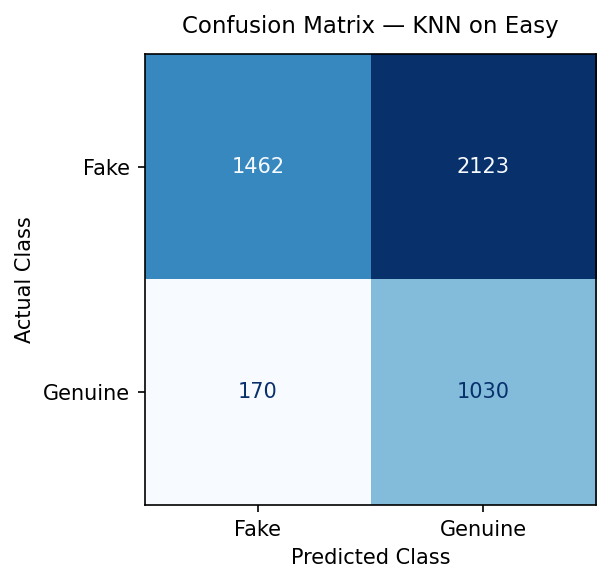

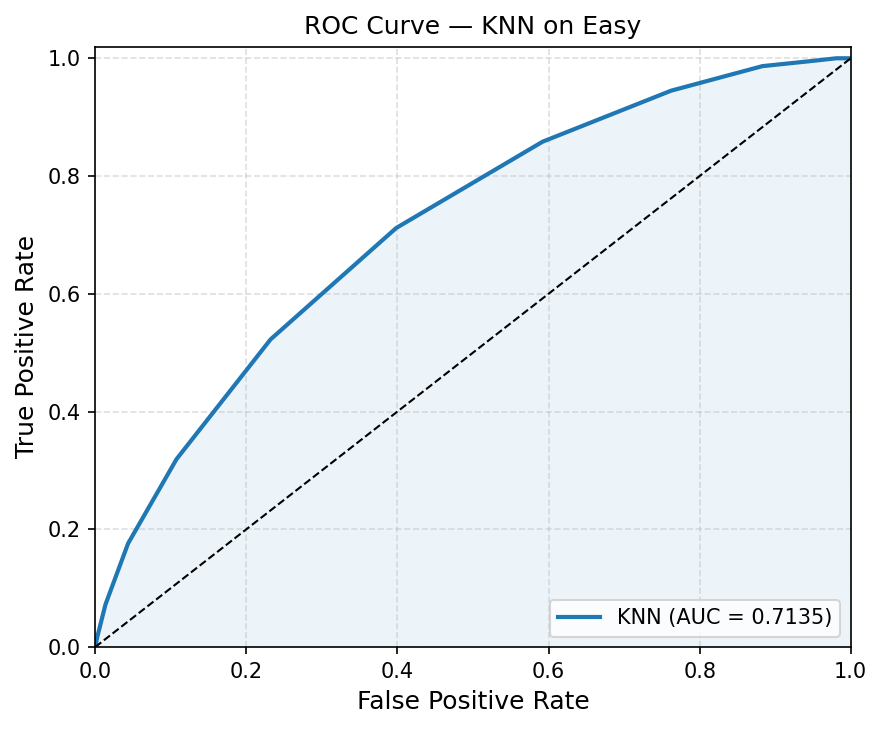

In [6]:
print('=' * 64)
print('SOCOFing EASY — KNN EXPERIMENT')
print('=' * 64)

# ── Raw dataset sizes (before split) ──
print(f'Raw Dataset  : {len(real_paths)} genuine  +  {len(easy_paths)} Altered-Easy fake')
print(f'              Total = {len(real_paths) + len(easy_paths)} images before split')
print(f'Sample Frac  : {SAMPLE_FRACTION} ("1.0" = full dataset, "0.01" = 1% test run)')

X_train, X_test, y_train, y_test = prepare_experiment_data(
    real_paths, easy_paths, sample_fraction=SAMPLE_FRACTION, random_state=RANDOM_STATE
)

feature_dim  = X_train.shape[1]
train_gen    = int((y_train == 1).sum())
train_fake   = int((y_train == 0).sum())
test_gen_n   = int((y_test == 1).sum())
test_fake_n  = int((y_test == 0).sum())

print(f'After Split  (80/20 GroupShuffleSplit by subject):')
print(f'  Train      : {X_train.shape[0]} images ({train_gen} genuine + {train_fake} fake, balanced)')
print(f'  Test       : {X_test.shape[0]} images ({test_gen_n} genuine + {test_fake_n} fake, natural imbalance)')
print(f'  Confusion matrix totals should sum to: {X_test.shape[0]}')
print(f'  Feature dim: {feature_dim}')

knn_grid = get_knn_pipeline(y_train)
knn_grid.fit(X_train, y_train)
y_pred_knn = knn_grid.predict(X_test)
y_prob_knn = knn_grid.predict_proba(X_test)[:, 1]

knn_metrics_easy = evaluate_pad_model(
    y_test, y_pred_knn, y_prob_knn,
    model_name='KNN', experiment_name='Easy',
    feature_dim=feature_dim, train_genuine=train_gen, train_fake=train_fake,
    best_params=knn_grid.best_params_, cv_roc_auc=knn_grid.best_score_
)
all_results.append(knn_metrics_easy)

print(f'Best Params  : {knn_grid.best_params_}')
print(f'Visual Results for KNN on Easy:')
display(Image(filename=os.path.join(OUTPUT_DIR, 'Easy', 'KNN_confusion_matrix.png')))
display(Image(filename=os.path.join(OUTPUT_DIR, 'Easy', 'KNN_roc.png')))


### Step 4.2: KNN on Medium Dataset

SOCOFing MEDIUM — KNN EXPERIMENT
Raw Dataset  : 6000 genuine  +  17067 Altered-Medium fake
              Total = 23067 images before split
Sample Frac  : 1 ("1.0" = full dataset, "0.01" = 1% test run)
  Extracting LBP features for 18465 training images and 4602 testing images...
After Split  (80/20 GroupShuffleSplit by subject):
  Train      : 9600 images (4800 genuine + 4800 fake, balanced)
  Test       : 4602 images (1200 genuine + 3402 fake, natural imbalance)
  Confusion matrix totals should sum to: 4602
  Feature dim: 640
Fitting 5 folds for each of 14 candidates, totalling 70 fits

════════════════════════════════════════════════════════════════
  KNN RESULTS  ·  Experiment: MEDIUM
════════════════════════════════════════════════════════════════
  DATASET SIZES
    Training  :   9600 images  (4800 genuine  +  4800 fake)  [balanced undersampled]
    Test      :   4602 images  (1200 genuine  +  3402 fake)  [natural imbalance]
    Features  : 640-dim LBP histogram  (8×8 blocks × 10 

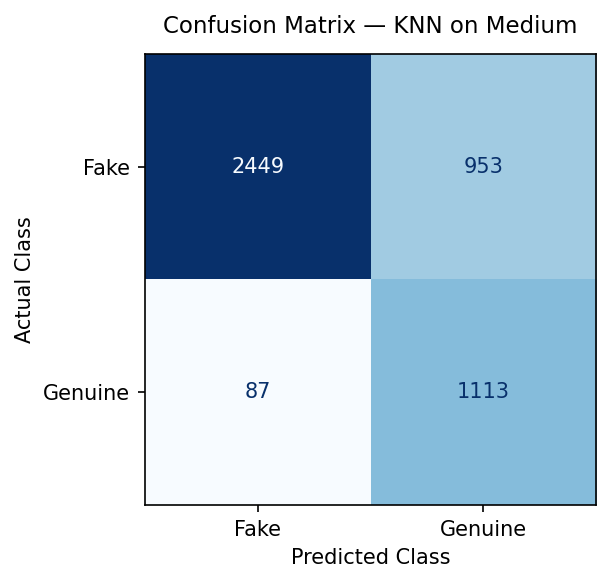

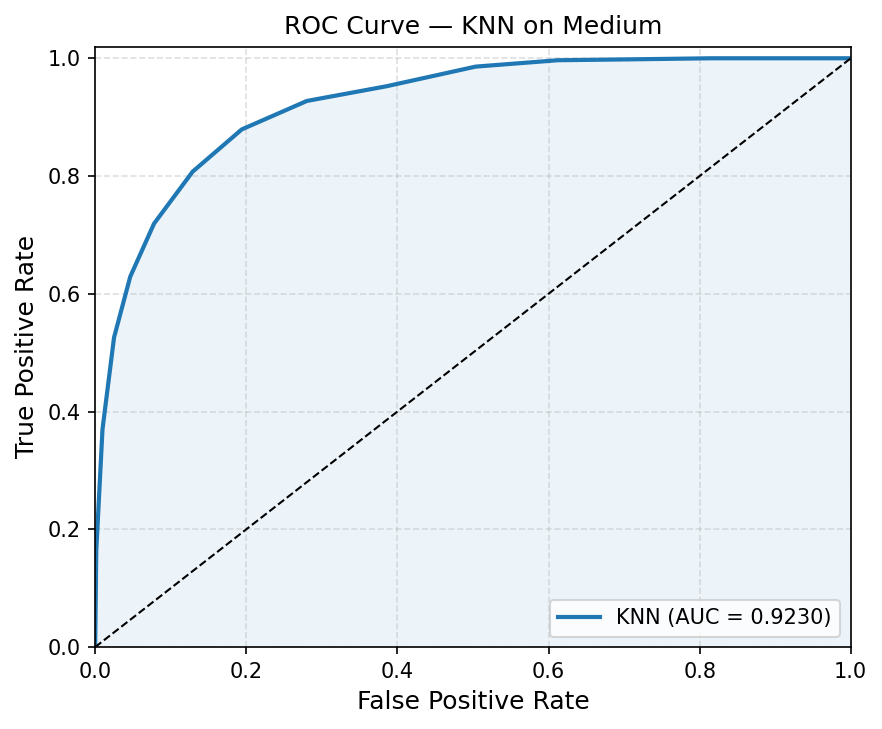

In [7]:
print('=' * 64)
print('SOCOFing MEDIUM — KNN EXPERIMENT')
print('=' * 64)

# ── Raw dataset sizes (before split) ──
print(f'Raw Dataset  : {len(real_paths)} genuine  +  {len(med_paths)} Altered-Medium fake')
print(f'              Total = {len(real_paths) + len(med_paths)} images before split')
print(f'Sample Frac  : {SAMPLE_FRACTION} ("1.0" = full dataset, "0.01" = 1% test run)')

X_train, X_test, y_train, y_test = prepare_experiment_data(
    real_paths, med_paths, sample_fraction=SAMPLE_FRACTION, random_state=RANDOM_STATE
)

feature_dim  = X_train.shape[1]
train_gen    = int((y_train == 1).sum())
train_fake   = int((y_train == 0).sum())
test_gen_n   = int((y_test == 1).sum())
test_fake_n  = int((y_test == 0).sum())

print(f'After Split  (80/20 GroupShuffleSplit by subject):')
print(f'  Train      : {X_train.shape[0]} images ({train_gen} genuine + {train_fake} fake, balanced)')
print(f'  Test       : {X_test.shape[0]} images ({test_gen_n} genuine + {test_fake_n} fake, natural imbalance)')
print(f'  Confusion matrix totals should sum to: {X_test.shape[0]}')
print(f'  Feature dim: {feature_dim}')

knn_grid = get_knn_pipeline(y_train)
knn_grid.fit(X_train, y_train)
y_pred_knn = knn_grid.predict(X_test)
y_prob_knn = knn_grid.predict_proba(X_test)[:, 1]

knn_metrics_medium = evaluate_pad_model(
    y_test, y_pred_knn, y_prob_knn,
    model_name='KNN', experiment_name='Medium',
    feature_dim=feature_dim, train_genuine=train_gen, train_fake=train_fake,
    best_params=knn_grid.best_params_, cv_roc_auc=knn_grid.best_score_
)
all_results.append(knn_metrics_medium)

print(f'Best Params  : {knn_grid.best_params_}')
print(f'Visual Results for KNN on Medium:')
display(Image(filename=os.path.join(OUTPUT_DIR, 'Medium', 'KNN_confusion_matrix.png')))
display(Image(filename=os.path.join(OUTPUT_DIR, 'Medium', 'KNN_roc.png')))


### Step 4.3: KNN on Hard Dataset

SOCOFing HARD — KNN EXPERIMENT
Raw Dataset  : 6000 genuine  +  14272 Altered-Hard fake
              Total = 20272 images before split
Sample Frac  : 1 ("1.0" = full dataset, "0.01" = 1% test run)
  Extracting LBP features for 16261 training images and 4011 testing images...
After Split  (80/20 GroupShuffleSplit by subject):
  Train      : 9600 images (4800 genuine + 4800 fake, balanced)
  Test       : 4011 images (1200 genuine + 2811 fake, natural imbalance)
  Confusion matrix totals should sum to: 4011
  Feature dim: 640
Fitting 5 folds for each of 14 candidates, totalling 70 fits

════════════════════════════════════════════════════════════════
  KNN RESULTS  ·  Experiment: HARD
════════════════════════════════════════════════════════════════
  DATASET SIZES
    Training  :   9600 images  (4800 genuine  +  4800 fake)  [balanced undersampled]
    Test      :   4011 images  (1200 genuine  +  2811 fake)  [natural imbalance]
    Features  : 640-dim LBP histogram  (8×8 blocks × 10 bins)


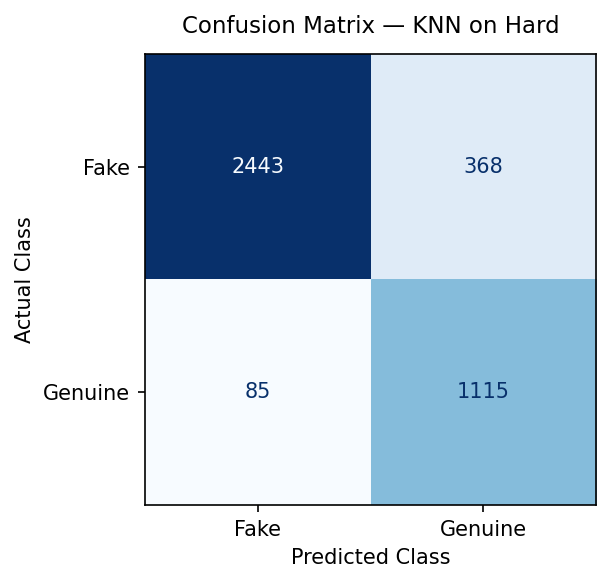

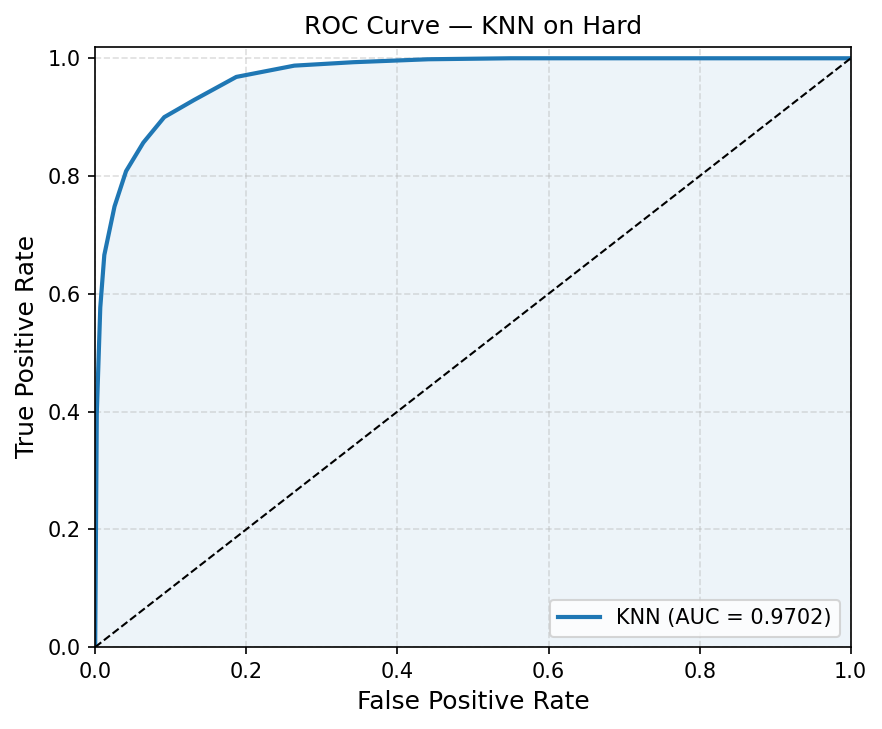

In [8]:
print('=' * 64)
print('SOCOFing HARD — KNN EXPERIMENT')
print('=' * 64)

# ── Raw dataset sizes (before split) ──
print(f'Raw Dataset  : {len(real_paths)} genuine  +  {len(hard_paths)} Altered-Hard fake')
print(f'              Total = {len(real_paths) + len(hard_paths)} images before split')
print(f'Sample Frac  : {SAMPLE_FRACTION} ("1.0" = full dataset, "0.01" = 1% test run)')

X_train, X_test, y_train, y_test = prepare_experiment_data(
    real_paths, hard_paths, sample_fraction=SAMPLE_FRACTION, random_state=RANDOM_STATE
)

feature_dim  = X_train.shape[1]
train_gen    = int((y_train == 1).sum())
train_fake   = int((y_train == 0).sum())
test_gen_n   = int((y_test == 1).sum())
test_fake_n  = int((y_test == 0).sum())

print(f'After Split  (80/20 GroupShuffleSplit by subject):')
print(f'  Train      : {X_train.shape[0]} images ({train_gen} genuine + {train_fake} fake, balanced)')
print(f'  Test       : {X_test.shape[0]} images ({test_gen_n} genuine + {test_fake_n} fake, natural imbalance)')
print(f'  Confusion matrix totals should sum to: {X_test.shape[0]}')
print(f'  Feature dim: {feature_dim}')

knn_grid = get_knn_pipeline(y_train)
knn_grid.fit(X_train, y_train)
y_pred_knn = knn_grid.predict(X_test)
y_prob_knn = knn_grid.predict_proba(X_test)[:, 1]

knn_metrics_hard = evaluate_pad_model(
    y_test, y_pred_knn, y_prob_knn,
    model_name='KNN', experiment_name='Hard',
    feature_dim=feature_dim, train_genuine=train_gen, train_fake=train_fake,
    best_params=knn_grid.best_params_, cv_roc_auc=knn_grid.best_score_
)
all_results.append(knn_metrics_hard)

print(f'Best Params  : {knn_grid.best_params_}')
print(f'Visual Results for KNN on Hard:')
display(Image(filename=os.path.join(OUTPUT_DIR, 'Hard', 'KNN_confusion_matrix.png')))
display(Image(filename=os.path.join(OUTPUT_DIR, 'Hard', 'KNN_roc.png')))


### Step 4.4: KNN on Combined Dataset

SOCOFing COMBINED — KNN EXPERIMENT
Raw Dataset  : 6000 genuine  +  49270 All Altered fake
              Total = 55270 images before split
Sample Frac  : 1 ("1.0" = full dataset, "0.01" = 1% test run)
  Extracting LBP features for 44272 training images and 10998 testing images...
After Split  (80/20 GroupShuffleSplit by subject):
  Train      : 9600 images (4800 genuine + 4800 fake, balanced)
  Test       : 10998 images (1200 genuine + 9798 fake, natural imbalance)
  Confusion matrix totals should sum to: 10998
  Feature dim: 640
Fitting 5 folds for each of 14 candidates, totalling 70 fits

════════════════════════════════════════════════════════════════
  KNN RESULTS  ·  Experiment: COMBINED
════════════════════════════════════════════════════════════════
  DATASET SIZES
    Training  :   9600 images  (4800 genuine  +  4800 fake)  [balanced undersampled]
    Test      :  10998 images  (1200 genuine  +  9798 fake)  [natural imbalance]
    Features  : 640-dim LBP histogram  (8×8 blocks ×

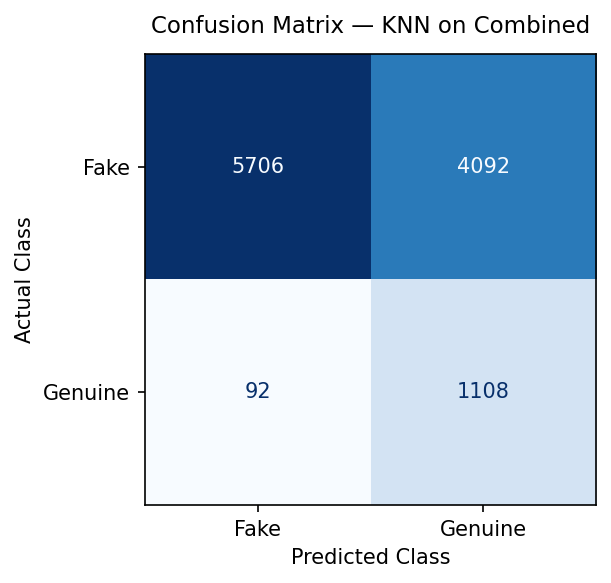

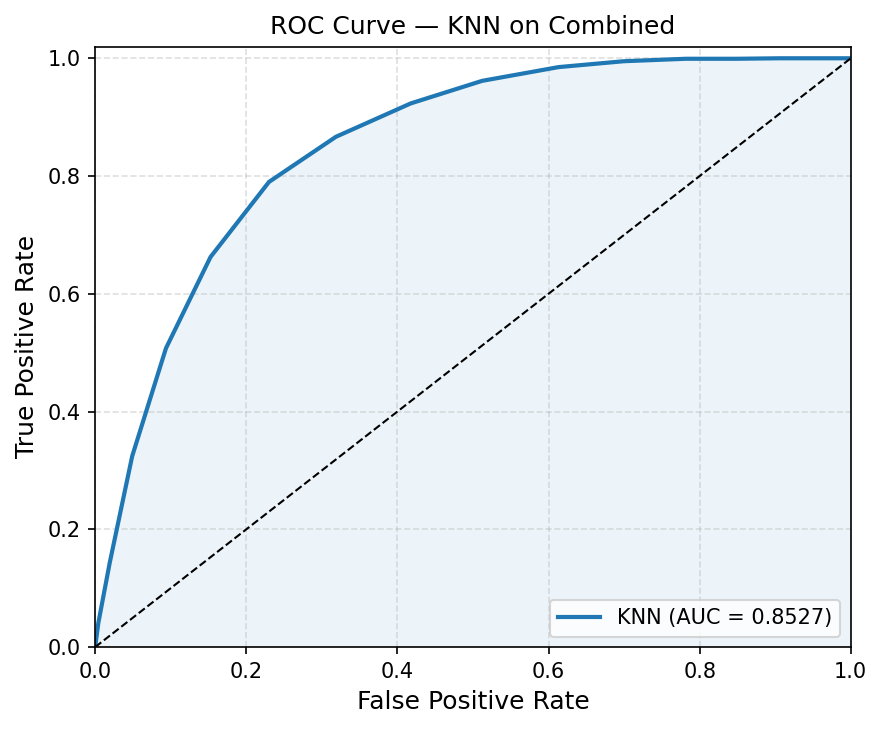

In [9]:
print('=' * 64)
print('SOCOFing COMBINED — KNN EXPERIMENT')
print('=' * 64)

# ── Raw dataset sizes (before split) ──
print(f'Raw Dataset  : {len(real_paths)} genuine  +  {len(all_fake_paths)} All Altered fake')
print(f'              Total = {len(real_paths) + len(all_fake_paths)} images before split')
print(f'Sample Frac  : {SAMPLE_FRACTION} ("1.0" = full dataset, "0.01" = 1% test run)')

X_train, X_test, y_train, y_test = prepare_experiment_data(
    real_paths, all_fake_paths, sample_fraction=SAMPLE_FRACTION, random_state=RANDOM_STATE
)

feature_dim  = X_train.shape[1]
train_gen    = int((y_train == 1).sum())
train_fake   = int((y_train == 0).sum())
test_gen_n   = int((y_test == 1).sum())
test_fake_n  = int((y_test == 0).sum())

print(f'After Split  (80/20 GroupShuffleSplit by subject):')
print(f'  Train      : {X_train.shape[0]} images ({train_gen} genuine + {train_fake} fake, balanced)')
print(f'  Test       : {X_test.shape[0]} images ({test_gen_n} genuine + {test_fake_n} fake, natural imbalance)')
print(f'  Confusion matrix totals should sum to: {X_test.shape[0]}')
print(f'  Feature dim: {feature_dim}')

knn_grid = get_knn_pipeline(y_train)
knn_grid.fit(X_train, y_train)
y_pred_knn = knn_grid.predict(X_test)
y_prob_knn = knn_grid.predict_proba(X_test)[:, 1]

knn_metrics_combined = evaluate_pad_model(
    y_test, y_pred_knn, y_prob_knn,
    model_name='KNN', experiment_name='Combined',
    feature_dim=feature_dim, train_genuine=train_gen, train_fake=train_fake,
    best_params=knn_grid.best_params_, cv_roc_auc=knn_grid.best_score_
)
all_results.append(knn_metrics_combined)

print(f'Best Params  : {knn_grid.best_params_}')
print(f'Visual Results for KNN on Combined:')
display(Image(filename=os.path.join(OUTPUT_DIR, 'Combined', 'KNN_confusion_matrix.png')))
display(Image(filename=os.path.join(OUTPUT_DIR, 'Combined', 'KNN_roc.png')))


## 5. SVM Experiments (Running Support Vector Machine Second)

Execute SVM (RBF Kernel) across all 4 difficulty levels: Easy, Medium, Hard, Combined.

### Step 5.1: SVM on Easy Dataset

SOCOFing EASY — SVM EXPERIMENT
Raw Dataset  : 6000 genuine  +  17931 Altered-Easy fake
              Total = 23931 images before split
Sample Frac  : 1 ("1.0" = full dataset, "0.01" = 1% test run)
  Extracting LBP features for 19146 training images and 4785 testing images...
After Split  (80/20 GroupShuffleSplit by subject):
  Train      : 9600 images (4800 genuine + 4800 fake, balanced)
  Test       : 4785 images (1200 genuine + 3585 fake, natural imbalance)
  Confusion matrix totals should sum to: 4785
  Feature dim: 640
Fitting 5 folds for each of 40 candidates, totalling 200 fits

════════════════════════════════════════════════════════════════
  SVM RESULTS  ·  Experiment: EASY
════════════════════════════════════════════════════════════════
  DATASET SIZES
    Training  :   9600 images  (4800 genuine  +  4800 fake)  [balanced undersampled]
    Test      :   4785 images  (1200 genuine  +  3585 fake)  [natural imbalance]
    Features  : 640-dim LBP histogram  (8×8 blocks × 10 bins)

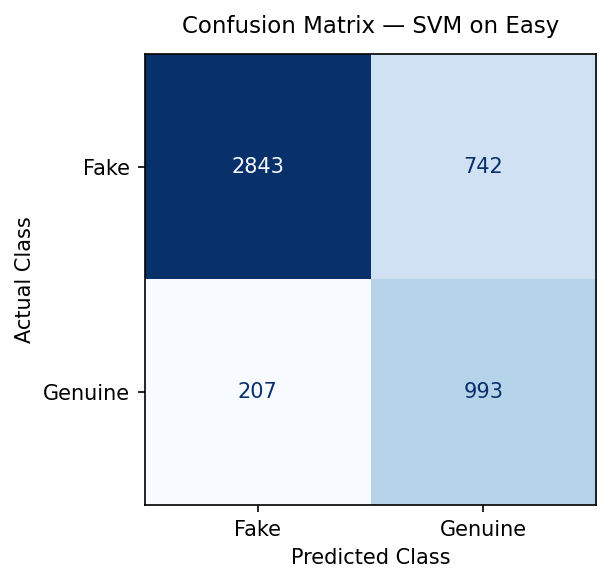

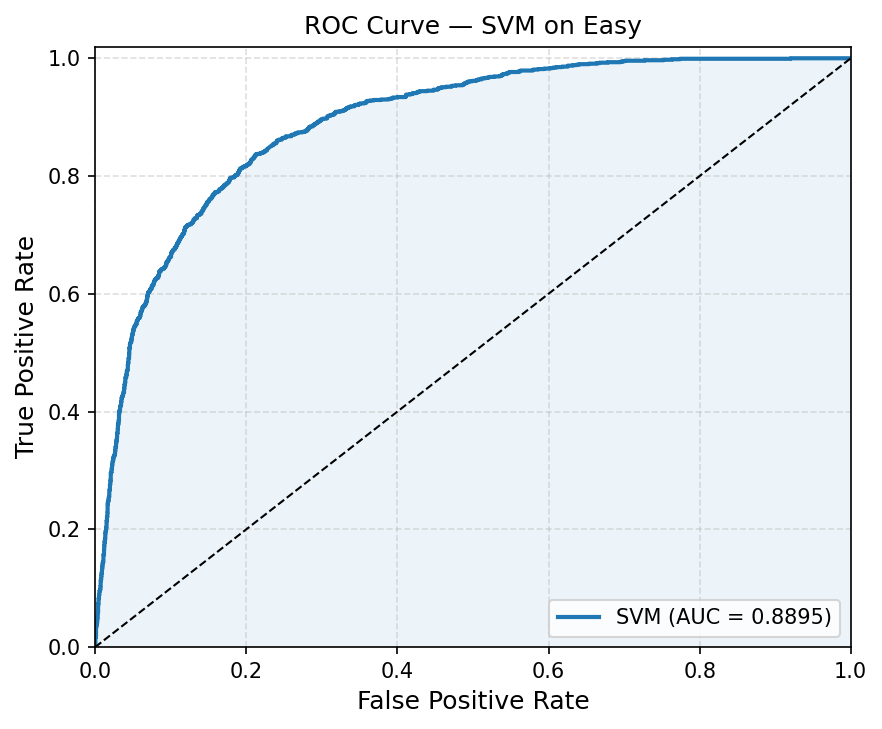

In [10]:
print('=' * 64)
print('SOCOFing EASY — SVM EXPERIMENT')
print('=' * 64)

# ── Raw dataset sizes (before split) ──
print(f'Raw Dataset  : {len(real_paths)} genuine  +  {len(easy_paths)} Altered-Easy fake')
print(f'              Total = {len(real_paths) + len(easy_paths)} images before split')
print(f'Sample Frac  : {SAMPLE_FRACTION} ("1.0" = full dataset, "0.01" = 1% test run)')

X_train, X_test, y_train, y_test = prepare_experiment_data(
    real_paths, easy_paths, sample_fraction=SAMPLE_FRACTION, random_state=RANDOM_STATE
)

feature_dim  = X_train.shape[1]
train_gen    = int((y_train == 1).sum())
train_fake   = int((y_train == 0).sum())
test_gen_n   = int((y_test == 1).sum())
test_fake_n  = int((y_test == 0).sum())

print(f'After Split  (80/20 GroupShuffleSplit by subject):')
print(f'  Train      : {X_train.shape[0]} images ({train_gen} genuine + {train_fake} fake, balanced)')
print(f'  Test       : {X_test.shape[0]} images ({test_gen_n} genuine + {test_fake_n} fake, natural imbalance)')
print(f'  Confusion matrix totals should sum to: {X_test.shape[0]}')
print(f'  Feature dim: {feature_dim}')

svm_grid = get_svm_pipeline(y_train)
svm_grid.fit(X_train, y_train)
y_pred_svm = svm_grid.predict(X_test)
y_prob_svm = svm_grid.predict_proba(X_test)[:, 1] if hasattr(svm_grid, 'predict_proba') else svm_grid.decision_function(X_test)

svm_metrics_easy = evaluate_pad_model(
    y_test, y_pred_svm, y_prob_svm,
    model_name='SVM', experiment_name='Easy',
    feature_dim=feature_dim, train_genuine=train_gen, train_fake=train_fake,
    best_params=svm_grid.best_params_, cv_roc_auc=svm_grid.best_score_
)
all_results.append(svm_metrics_easy)

print(f'Best Params  : {svm_grid.best_params_}')
print(f'Visual Results for SVM on Easy:')
display(Image(filename=os.path.join(OUTPUT_DIR, 'Easy', 'SVM_confusion_matrix.png')))
display(Image(filename=os.path.join(OUTPUT_DIR, 'Easy', 'SVM_roc.png')))


### Step 5.2: SVM on Medium Dataset

SOCOFing MEDIUM — SVM EXPERIMENT
Raw Dataset  : 6000 genuine  +  17067 Altered-Medium fake
              Total = 23067 images before split
Sample Frac  : 1 ("1.0" = full dataset, "0.01" = 1% test run)
  Extracting LBP features for 18465 training images and 4602 testing images...
After Split  (80/20 GroupShuffleSplit by subject):
  Train      : 9600 images (4800 genuine + 4800 fake, balanced)
  Test       : 4602 images (1200 genuine + 3402 fake, natural imbalance)
  Confusion matrix totals should sum to: 4602
  Feature dim: 640
Fitting 5 folds for each of 40 candidates, totalling 200 fits

════════════════════════════════════════════════════════════════
  SVM RESULTS  ·  Experiment: MEDIUM
════════════════════════════════════════════════════════════════
  DATASET SIZES
    Training  :   9600 images  (4800 genuine  +  4800 fake)  [balanced undersampled]
    Test      :   4602 images  (1200 genuine  +  3402 fake)  [natural imbalance]
    Features  : 640-dim LBP histogram  (8×8 blocks × 10

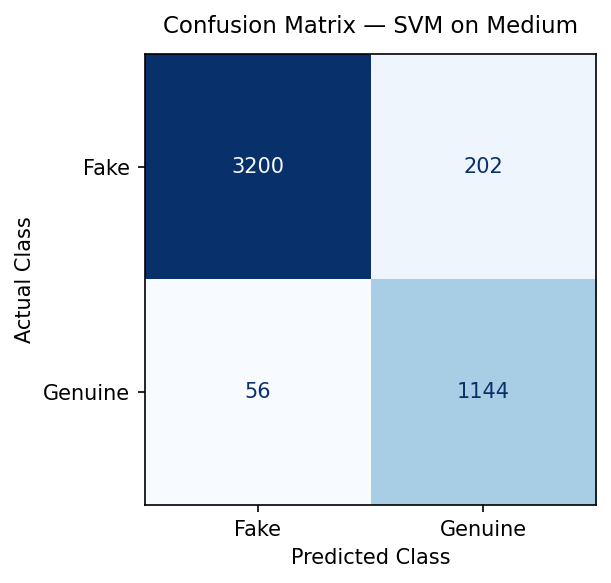

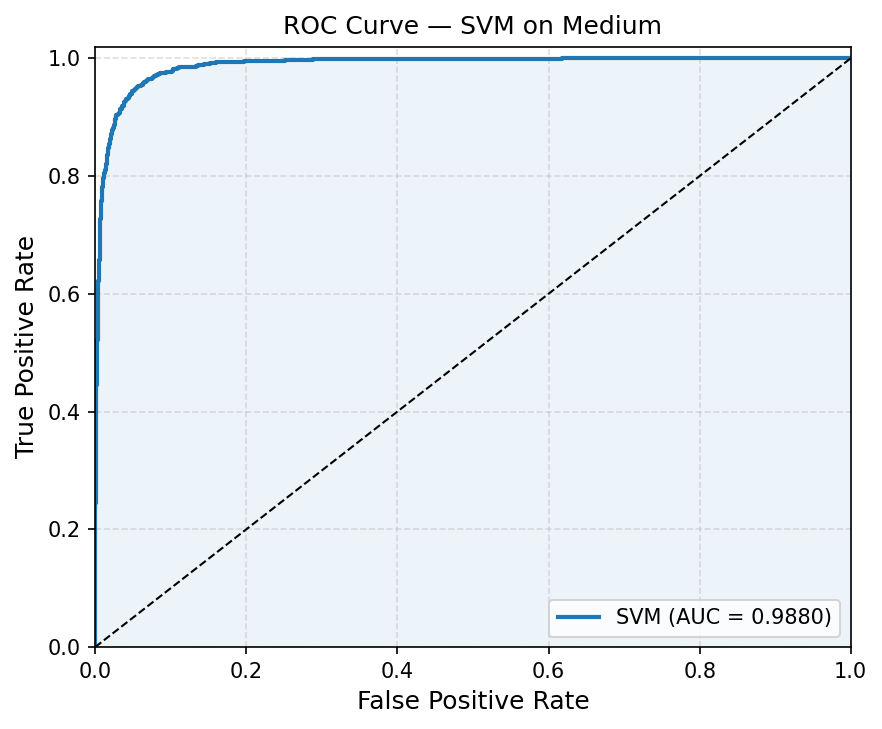

In [11]:
print('=' * 64)
print('SOCOFing MEDIUM — SVM EXPERIMENT')
print('=' * 64)

# ── Raw dataset sizes (before split) ──
print(f'Raw Dataset  : {len(real_paths)} genuine  +  {len(med_paths)} Altered-Medium fake')
print(f'              Total = {len(real_paths) + len(med_paths)} images before split')
print(f'Sample Frac  : {SAMPLE_FRACTION} ("1.0" = full dataset, "0.01" = 1% test run)')

X_train, X_test, y_train, y_test = prepare_experiment_data(
    real_paths, med_paths, sample_fraction=SAMPLE_FRACTION, random_state=RANDOM_STATE
)

feature_dim  = X_train.shape[1]
train_gen    = int((y_train == 1).sum())
train_fake   = int((y_train == 0).sum())
test_gen_n   = int((y_test == 1).sum())
test_fake_n  = int((y_test == 0).sum())

print(f'After Split  (80/20 GroupShuffleSplit by subject):')
print(f'  Train      : {X_train.shape[0]} images ({train_gen} genuine + {train_fake} fake, balanced)')
print(f'  Test       : {X_test.shape[0]} images ({test_gen_n} genuine + {test_fake_n} fake, natural imbalance)')
print(f'  Confusion matrix totals should sum to: {X_test.shape[0]}')
print(f'  Feature dim: {feature_dim}')

svm_grid = get_svm_pipeline(y_train)
svm_grid.fit(X_train, y_train)
y_pred_svm = svm_grid.predict(X_test)
y_prob_svm = svm_grid.predict_proba(X_test)[:, 1] if hasattr(svm_grid, 'predict_proba') else svm_grid.decision_function(X_test)

svm_metrics_medium = evaluate_pad_model(
    y_test, y_pred_svm, y_prob_svm,
    model_name='SVM', experiment_name='Medium',
    feature_dim=feature_dim, train_genuine=train_gen, train_fake=train_fake,
    best_params=svm_grid.best_params_, cv_roc_auc=svm_grid.best_score_
)
all_results.append(svm_metrics_medium)

print(f'Best Params  : {svm_grid.best_params_}')
print(f'Visual Results for SVM on Medium:')
display(Image(filename=os.path.join(OUTPUT_DIR, 'Medium', 'SVM_confusion_matrix.png')))
display(Image(filename=os.path.join(OUTPUT_DIR, 'Medium', 'SVM_roc.png')))


### Step 5.3: SVM on Hard Dataset

SOCOFing HARD — SVM EXPERIMENT
Raw Dataset  : 6000 genuine  +  14272 Altered-Hard fake
              Total = 20272 images before split
Sample Frac  : 1 ("1.0" = full dataset, "0.01" = 1% test run)
  Extracting LBP features for 16261 training images and 4011 testing images...
After Split  (80/20 GroupShuffleSplit by subject):
  Train      : 9600 images (4800 genuine + 4800 fake, balanced)
  Test       : 4011 images (1200 genuine + 2811 fake, natural imbalance)
  Confusion matrix totals should sum to: 4011
  Feature dim: 640
Fitting 5 folds for each of 40 candidates, totalling 200 fits

════════════════════════════════════════════════════════════════
  SVM RESULTS  ·  Experiment: HARD
════════════════════════════════════════════════════════════════
  DATASET SIZES
    Training  :   9600 images  (4800 genuine  +  4800 fake)  [balanced undersampled]
    Test      :   4011 images  (1200 genuine  +  2811 fake)  [natural imbalance]
    Features  : 640-dim LBP histogram  (8×8 blocks × 10 bins)

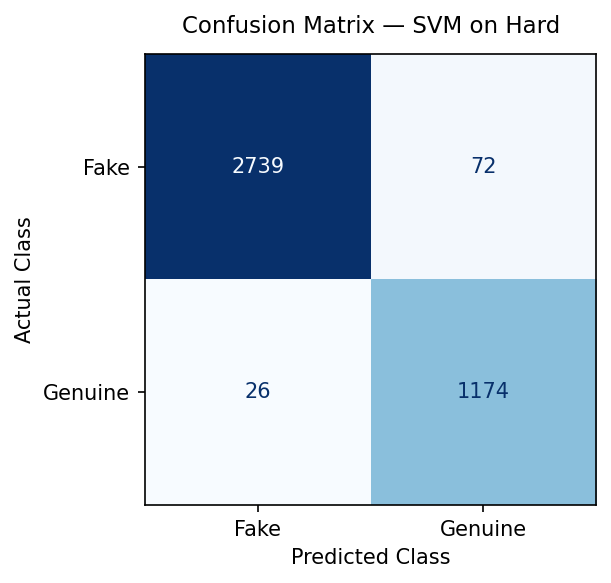

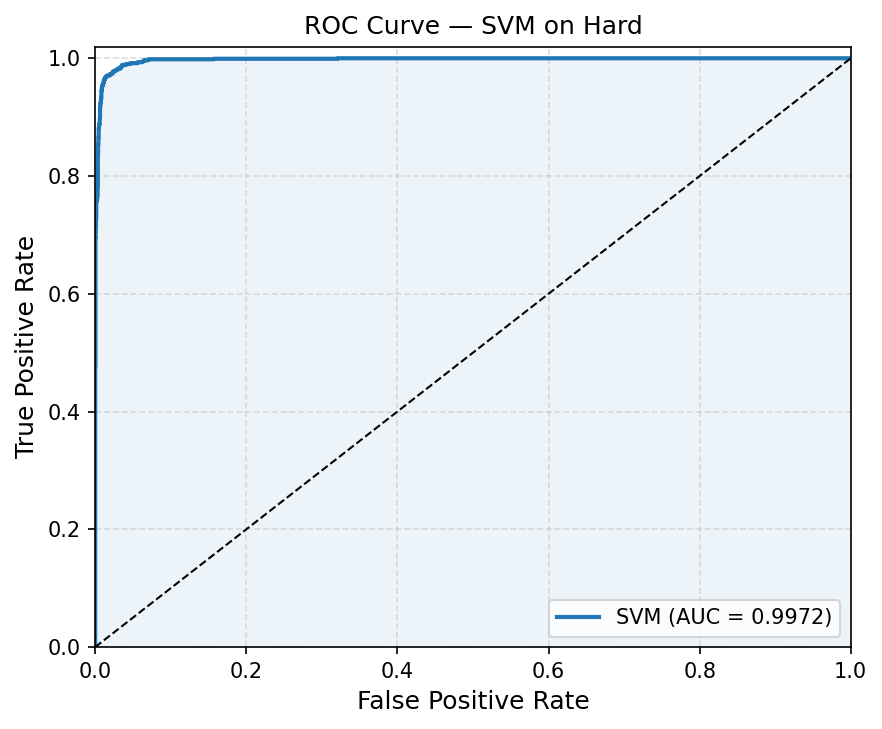

In [12]:
print('=' * 64)
print('SOCOFing HARD — SVM EXPERIMENT')
print('=' * 64)

# ── Raw dataset sizes (before split) ──
print(f'Raw Dataset  : {len(real_paths)} genuine  +  {len(hard_paths)} Altered-Hard fake')
print(f'              Total = {len(real_paths) + len(hard_paths)} images before split')
print(f'Sample Frac  : {SAMPLE_FRACTION} ("1.0" = full dataset, "0.01" = 1% test run)')

X_train, X_test, y_train, y_test = prepare_experiment_data(
    real_paths, hard_paths, sample_fraction=SAMPLE_FRACTION, random_state=RANDOM_STATE
)

feature_dim  = X_train.shape[1]
train_gen    = int((y_train == 1).sum())
train_fake   = int((y_train == 0).sum())
test_gen_n   = int((y_test == 1).sum())
test_fake_n  = int((y_test == 0).sum())

print(f'After Split  (80/20 GroupShuffleSplit by subject):')
print(f'  Train      : {X_train.shape[0]} images ({train_gen} genuine + {train_fake} fake, balanced)')
print(f'  Test       : {X_test.shape[0]} images ({test_gen_n} genuine + {test_fake_n} fake, natural imbalance)')
print(f'  Confusion matrix totals should sum to: {X_test.shape[0]}')
print(f'  Feature dim: {feature_dim}')

svm_grid = get_svm_pipeline(y_train)
svm_grid.fit(X_train, y_train)
y_pred_svm = svm_grid.predict(X_test)
y_prob_svm = svm_grid.predict_proba(X_test)[:, 1] if hasattr(svm_grid, 'predict_proba') else svm_grid.decision_function(X_test)

svm_metrics_hard = evaluate_pad_model(
    y_test, y_pred_svm, y_prob_svm,
    model_name='SVM', experiment_name='Hard',
    feature_dim=feature_dim, train_genuine=train_gen, train_fake=train_fake,
    best_params=svm_grid.best_params_, cv_roc_auc=svm_grid.best_score_
)
all_results.append(svm_metrics_hard)

print(f'Best Params  : {svm_grid.best_params_}')
print(f'Visual Results for SVM on Hard:')
display(Image(filename=os.path.join(OUTPUT_DIR, 'Hard', 'SVM_confusion_matrix.png')))
display(Image(filename=os.path.join(OUTPUT_DIR, 'Hard', 'SVM_roc.png')))


### Step 5.4: SVM on Combined Dataset

SOCOFing COMBINED — SVM EXPERIMENT
Raw Dataset  : 6000 genuine  +  49270 All Altered fake
              Total = 55270 images before split
Sample Frac  : 1 ("1.0" = full dataset, "0.01" = 1% test run)
  Extracting LBP features for 44272 training images and 10998 testing images...
After Split  (80/20 GroupShuffleSplit by subject):
  Train      : 9600 images (4800 genuine + 4800 fake, balanced)
  Test       : 10998 images (1200 genuine + 9798 fake, natural imbalance)
  Confusion matrix totals should sum to: 10998
  Feature dim: 640
Fitting 5 folds for each of 40 candidates, totalling 200 fits

════════════════════════════════════════════════════════════════
  SVM RESULTS  ·  Experiment: COMBINED
════════════════════════════════════════════════════════════════
  DATASET SIZES
    Training  :   9600 images  (4800 genuine  +  4800 fake)  [balanced undersampled]
    Test      :  10998 images  (1200 genuine  +  9798 fake)  [natural imbalance]
    Features  : 640-dim LBP histogram  (8×8 blocks 

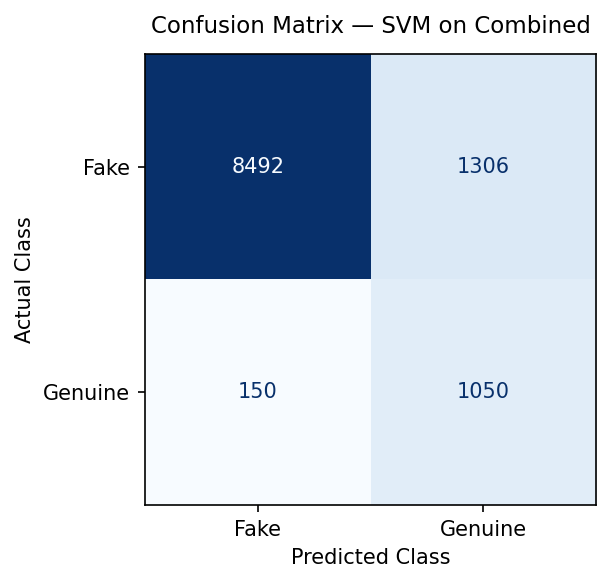

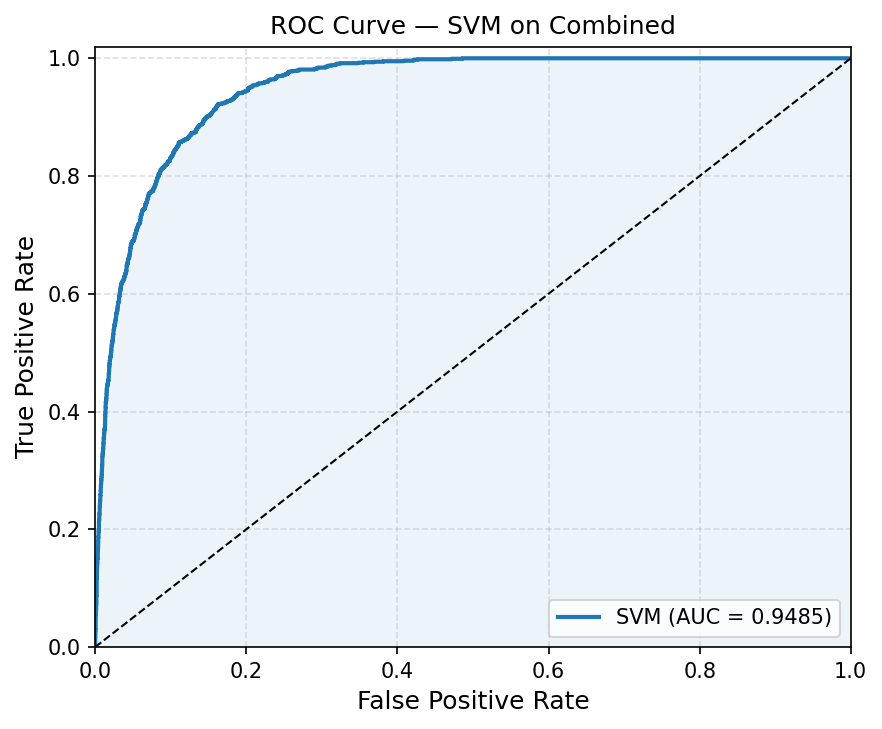

In [6]:
print('=' * 64)
print('SOCOFing COMBINED — SVM EXPERIMENT')
print('=' * 64)

# ── Raw dataset sizes (before split) ──
print(f'Raw Dataset  : {len(real_paths)} genuine  +  {len(all_fake_paths)} All Altered fake')
print(f'              Total = {len(real_paths) + len(all_fake_paths)} images before split')
print(f'Sample Frac  : {SAMPLE_FRACTION} ("1.0" = full dataset, "0.01" = 1% test run)')

X_train, X_test, y_train, y_test = prepare_experiment_data(
    real_paths, all_fake_paths, sample_fraction=SAMPLE_FRACTION, random_state=RANDOM_STATE
)

feature_dim  = X_train.shape[1]
train_gen    = int((y_train == 1).sum())
train_fake   = int((y_train == 0).sum())
test_gen_n   = int((y_test == 1).sum())
test_fake_n  = int((y_test == 0).sum())

print(f'After Split  (80/20 GroupShuffleSplit by subject):')
print(f'  Train      : {X_train.shape[0]} images ({train_gen} genuine + {train_fake} fake, balanced)')
print(f'  Test       : {X_test.shape[0]} images ({test_gen_n} genuine + {test_fake_n} fake, natural imbalance)')
print(f'  Confusion matrix totals should sum to: {X_test.shape[0]}')
print(f'  Feature dim: {feature_dim}')

svm_grid = get_svm_pipeline(y_train)
svm_grid.fit(X_train, y_train)
y_pred_svm = svm_grid.predict(X_test)
y_prob_svm = svm_grid.predict_proba(X_test)[:, 1] if hasattr(svm_grid, 'predict_proba') else svm_grid.decision_function(X_test)

svm_metrics_combined = evaluate_pad_model(
    y_test, y_pred_svm, y_prob_svm,
    model_name='SVM', experiment_name='Combined',
    feature_dim=feature_dim, train_genuine=train_gen, train_fake=train_fake,
    best_params=svm_grid.best_params_, cv_roc_auc=svm_grid.best_score_
)
all_results.append(svm_metrics_combined)

print(f'Best Params  : {svm_grid.best_params_}')
print(f'Visual Results for SVM on Combined:')
display(Image(filename=os.path.join(OUTPUT_DIR, 'Combined', 'SVM_confusion_matrix.png')))
display(Image(filename=os.path.join(OUTPUT_DIR, 'Combined', 'SVM_roc.png')))


## 6. Final Consolidated Scientific Results & Export

Export all metrics to `results_full/SOCOFing_LBP_all_results.csv` and display the final comparison table, confusion matrix breakdown, and difficulty degradation analysis.

In [ ]:
# ── Completeness check ──────────────────────────────────────────────────────
# all_results is populated by cells 12, 14, 16, 18 (KNN: Easy/Medium/Hard/Combined)
# and 21, 23, 25, 27 (SVM: Easy/Medium/Hard/Combined). If the notebook was run
# out of order, or the kernel was restarted mid-way (which resets all_results
# to [] in the "Global results list" cell above), this table will silently show
# only whichever experiments happened to run before this cell. Catch that here
# instead of shipping a partial table.
EXPECTED_EXPERIMENTS = ["Easy", "Medium", "Hard", "Combined"]
EXPECTED_MODELS = ["KNN", "SVM"]
EXPECTED_COMBOS = {(exp, model) for exp in EXPECTED_EXPERIMENTS for model in EXPECTED_MODELS}

present_combos = {(r["Experiment"], r["Model"]) for r in all_results}
missing_combos = EXPECTED_COMBOS - present_combos

if missing_combos:
    missing_sorted = sorted(missing_combos, key=lambda c: (EXPECTED_EXPERIMENTS.index(c[0]), c[1]))
    print("⚠ WARNING: all_results is missing", len(missing_combos), "of", len(EXPECTED_COMBOS), "expected experiment/model combinations:")
    for exp, model in missing_sorted:
        print(f"    - {model} on {exp}")
    print("  Re-run the KNN (cells 12/14/16/18) and SVM (cells 21/23/25/27) experiment cells,")
    print("  in order, in this same kernel session (do NOT restart the kernel in between —")
    print("  that resets all_results to []). The table below only reflects what's present now.\n")
else:
    print(f"✓ All {len(EXPECTED_COMBOS)} experiment/model combinations present ({len(EXPECTED_EXPERIMENTS)} experiments × {len(EXPECTED_MODELS)} models).\n")

df_all = pd.DataFrame(all_results)
csv_out_path = os.path.join(OUTPUT_DIR, "SOCOFing_LBP_all_results.csv")
df_all.to_csv(csv_out_path, index=False)
print(f"✓ Saved full results table to {csv_out_path}")

print(f"\n{'='*68}")
print("SOCOFing LBP PAD FINAL COMPARISON TABLE")
print(f"{'='*68}")
cols_to_show = ["Experiment", "Model", "TrainSamples", "TestSamples", "ROC_AUC", "PR_AUC", "Accuracy", "BalancedAccuracy", "MacroF1", "MCC", "FalseAcceptanceRate", "FalseRejectionRate"]
# Sort so all 4 experiments x 2 models line up in a stable, readable order
exp_order = {e: i for i, e in enumerate(EXPECTED_EXPERIMENTS)}
df_all["_exp_order"] = df_all["Experiment"].map(exp_order).fillna(len(EXPECTED_EXPERIMENTS))
df_all = df_all.sort_values(["_exp_order", "Model"]).drop(columns="_exp_order").reset_index(drop=True)
display(df_all[cols_to_show])

print("\n========================================================================================")
print("  CONFUSION MATRIX DETAILED COUNTS TABLE (TN, FP, FN, TP, FAR, FRR)")
print("========================================================================================")
rows = []
for _, r in df_all.iterrows():
    test_fake = r['TestFake']
    test_gen = r['TestGenuine']
    far = r['FalseAcceptanceRate']
    frr = r['FalseRejectionRate']

    fp = int(round(far * test_fake))
    tn = int(test_fake - fp)
    fn = int(round(frr * test_gen))
    tp = int(test_gen - fn)

    rows.append({
        "Experiment": r['Experiment'],
        "Model": r['Model'],
        "Test Total": r['TestSamples'],
        "TN (Fake -> Fake)": tn,
        "FP (Fake -> Genuine)": fp,
        "FN (Genuine -> Fake)": fn,
        "TP (Genuine -> Genuine)": tp,
        "FAR (False Accept)": f"{far*100:.2f}%",
        "FRR (False Reject)": f"{frr*100:.2f}%",
        "Accuracy": f"{r['Accuracy']*100:.2f}%",
        "ROC-AUC": f"{r['ROC_AUC']:.4f}"
    })

cm_df = pd.DataFrame(rows)
display(cm_df)

# Difficulty Analysis
svm_df = df_all[df_all['Model'] == 'SVM'].set_index('Experiment')
knn_df = df_all[df_all['Model'] == 'KNN'].set_index('Experiment')

if 'Easy' in svm_df.index and 'Medium' in svm_df.index and 'Hard' in svm_df.index:
    print("\n--- DIFFICULTY DEGRADATION ANALYSIS ---")
    print("Easy -> Medium change:")
    print(f"  SVM ROC-AUC: {svm_df.loc['Medium', 'ROC_AUC'] - svm_df.loc['Easy', 'ROC_AUC']:+.4f}")
    print(f"  KNN ROC-AUC: {knn_df.loc['Medium', 'ROC_AUC'] - knn_df.loc['Easy', 'ROC_AUC']:+.4f}")

    print("\nMedium -> Hard change:")
    print(f"  SVM ROC-AUC: {svm_df.loc['Hard', 'ROC_AUC'] - svm_df.loc['Medium', 'ROC_AUC']:+.4f}")
    print(f"  KNN ROC-AUC: {knn_df.loc['Hard', 'ROC_AUC'] - knn_df.loc['Medium', 'ROC_AUC']:+.4f}")

    print("\nEasy -> Hard change:")
    print(f"  SVM ROC-AUC: {svm_df.loc['Hard', 'ROC_AUC'] - svm_df.loc['Easy', 'ROC_AUC']:+.4f}")
    print(f"  KNN ROC-AUC: {knn_df.loc['Hard', 'ROC_AUC'] - knn_df.loc['Easy', 'ROC_AUC']:+.4f}")
